<a href="https://colab.research.google.com/github/nebiolabs/domainator_examples/blob/main/colab_notebooks/Domainator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction

This Notebook automatically installs Domainator and its dependencies, giving you a sandbox to try out the different programs. For full documentation, see the [readme](https://github.com/nebiolabs/domainator/tree/main).

For specific examples to follow along with, see:

- [Basic Examples](https://github.com/nebiolabs/domainator/blob/main/docs/examples.md)
  - These examples assume a command line environment so to use in Colab, you need to prefix all of the commands with `!`.
  - Most of these examples are already included below in this notebook.
- [Advanced Examples](https://github.com/nebiolabs/domainator_examples)
  - These examples are from a python notebook environment, so you can copy and paste the code directly into Colab.

##Most of the programs in Domainator and how their inputs and outputs can be chained
(Note: not all Domainator programs are shown below)
<img src="https://raw.githubusercontent.com/nebiolabs/domainator/main/docs/media/Overview_diagram.png" alt="Domainator programs" width="800"/>

##The most common workflow for Domainator-based analyses
<img src="https://raw.githubusercontent.com/nebiolabs/domainator/main/docs/media/genome_mining_workflow.png" alt="Workflow" width="600"/>




In [1]:
#@title Install dependencies

!mkdir programs
!mkdir /opt/bin
!rm -r sample_data

# cd-hit
!cd programs && wget https://github.com/weizhongli/cdhit/releases/download/V4.8.1/cd-hit-v4.8.1-2019-0228.tar.gz > /dev/null 2>&1
!cd programs && tar xf cd-hit-v4.8.1-2019-0228.tar.gz > /dev/null 2>&1
!cd programs/cd-hit-v4.8.1-2019-0228/ && make > /dev/null 2>&1 && cp cd-hit cd-hit-est /opt/bin

# Diamond
!cd programs && wget https://github.com/bbuchfink/diamond/releases/download/v2.1.9/diamond-linux64.tar.gz > /dev/null 2>&1
!cd programs && tar xf diamond-linux64.tar.gz && cp diamond /opt/bin

# # Hmmer command line #TODO: not really a dependency (we use pyhmmer), but sometimes people expect that it will be installed in the environment
# !cd programs && wget http://eddylab.org/software/hmmer/hmmer-3.4.tar.gz > /dev/null 2>&1
# !cd programs && tar xf hmmer-3.4.tar.gz
# !cd programs/hmmer-3.4 && ./configure --prefix /opt > /dev/null 2>&1 && make > /dev/null 2>&1 && make install > /dev/null 2>&1

# Usearch
!cd programs && wget https://raw.githubusercontent.com/rcedgar/usearch_old_binaries/main/bin/usearch11.0.667_i86linux64 > /dev/null 2>&1 && chmod a+x usearch11.0.667_i86linux64 && cp usearch11.0.667_i86linux64 /opt/bin/usearch

# Domainator
!cd programs && git clone https://github.com/nebiolabs/domainator > /dev/null 2>&1 #TODO: should this be a specific version?
!cd programs/domainator && pip install -q . > /dev/null 2>&1


# imports
from pathlib import Path
from google.colab import files
import IPython

Domainator tools are called from the Colab command line using `! [program_name].py`. The `!` at the beginning is necessary to tell Colab that it is a command line call.

Documentation for individual programs can be accessed using the `-h` command line option. For example `domainate.py -h`.


Upload any data files you're interested in to the default Colab folder:

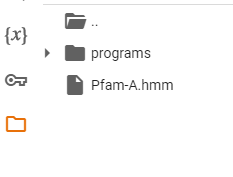

# Basic Examples

In [ ]:
#@title Download and prepare data for basic examples
!wget https://zenodo.org/records/10989173/files/ncbi_complete_subset.gb # about 800 Mb of various prokaryote genomes
!wget https://zenodo.org/records/10999789/files/example_files.tar.gz
!tar -xf example_files.tar.gz
!hmmer_select.py -i example_files/example_hmms.hmm --exact Sod_Fe_C -o Sod_Fe_C.hmm

#Run domainate.py on a single file to add putative functional annotations

In [6]:
#@markdown Add domain annotations to GenBank input with CDS locations already annotated. The results will be "annotated.gb" and a plot file called "contigs_plot.html".
!rm -f annotated.gb contigs_plot.html
!domainate.py --cpu 4 -i example_files/pDONR201_genemark.gb -r example_files/example_hmms.hmm -o annotated.gb --max_overlap 0.6
!plot_contigs.py -i annotated.gb --html contigs_plot.html

if Path("contigs_plot.html").is_file():
 files.download("contigs_plot.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
#@markdown Add domain annotations to protein fasta input. The results will be "annotated.gb" and a plot file called "contigs_plot.html".
!rm -f annotated.gb contigs_plot.html
!domainate.py --cpu 4 -i example_files/example_peptides.fasta -r example_files/example_hmms.hmm -o annotated.gb --max_overlap 0.6
!plot_contigs.py -i annotated.gb --html contigs_plot.html
if Path("contigs_plot.html").is_file():
 files.download("contigs_plot.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
#@markdown Add CDS location annotations and protein domain annotations to DNA fasta input. The results will be "annotated.gb" and a plot file called "contigs_plot.html".

!rm -f annotated.gb contigs_plot.html
!domainate.py --gene_call all --fasta_type nucleotide --cpu 4 -i example_files/pDONR201_multi.fasta -r example_files/example_hmms.hmm -o annotated.gb --max_overlap 0.6
!plot_contigs.py -i annotated.gb --html contigs_plot.html
if Path("contigs_plot.html").is_file():
 files.download("contigs_plot.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
#@markdown Protein fasta reference files. Uses phmmer (instead of hmmscan) to add annotations to GenBank input with CDS locations already annotated. The results will be "annotated.gb" and a plot file called "contigs_plot.html".
!rm -f annotated.gb contigs_plot.html
!domainate.py --cpu 4 -i example_files/pDONR201_genemark.gb -r example_files/example_peptides.fasta -o annotated.gb --max_overlap 0.6
!plot_contigs.py -i annotated.gb --html contigs_plot.html
if Path("contigs_plot.html").is_file():
 files.download("contigs_plot.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
#@title Run domainate.py on a multiple input files to add putative functional annotations

#@markdown You can have multiple input files. In this example, one of the inputs is a nucleotide genbank file with CDS annotations already present and the other is a fasta file with no annotations. setting `--gene_call` unannotated will find CDSs in any contig that doesn't have at least one CDS annotation already.

#@markdown You can also search multiple domain databases at once by supplying multiple hmm or protein fasta files via the `-r` option. Not all of the reference sequences have to be of the same type. Some can be protein sequences and some can be hmm files in the same call to domainate.

#@markdown You can also run domainate sequentially, meaning you can run an already annotated genbank file through the domainator program again with a different domain database. Options such as `--max_overlap` and `--max_domains` are only applied to newly added annotations.

!rm -f annotated.gb contigs_plot.html
!domainate.py --fasta_type nucleotide --gene_call unannotated --cpu 4 -o annotated.gb -r example_files/example_hmms.hmm --max_overlap 0.6 -i example_files/pDONR201_genemark.gb example_files/pDONR201_multi.fasta
!plot_contigs.py -i annotated.gb --html contigs_plot.html
if Path("contigs_plot.html").is_file():
 files.download("contigs_plot.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Visualizing output

In [11]:
!rm -f annotated.gb domain_summary.html enum_report.html enum_report.tsv annotated_colored.gb contigs_plot.html annotated_colored.gb
import IPython
#@markdown Adds functional domain annotations to a set of contigs, then generates three kinds of reports.
#@markdown - `summary_report.html`: Tells the number of contigs, the number of CDSs, the density of CDSs, a histogram of contig lengths, and a table of domain frequencies.
#@markdown - `enum_report.html` and `enum_report.tsv`: Tabular reports showing name, description, taxonomy information, length, and domain content for each contig. enum_report.py is very versatile and can report many different properties. Each line can be a contig, CDS, or individual domain annotation, according to user settings.
#@markdown - `contigs_plot.html`: A visual plot of the contigs showing the CDS locations and domain annotation locations. (Due to technical limitations, contigs_plots cannot be displayed in-line in Colab)


# make sure there is an annotated genbank file to plot.
!domainate.py --fasta_type nucleotide --gene_call unannotated --cpu 4 -o annotated.gb -r example_files/example_hmms.hmm --max_overlap 0.6 -i example_files/pDONR201_genemark.gb example_files/pDONR201_multi.fasta

!summary_report.py -i annotated.gb --html domain_summary.html
!enum_report.py -i annotated.gb --by contig --definition --taxname superkingdom genus species self --length --domains --html enum_report.html -o enum_report.tsv
!color_genbank.py -i annotated.gb -o annotated_colored.gb --color_domains
!plot_contigs.py -i annotated_colored.gb --html contigs_plot.html

if Path("contigs_plot.html").is_file():
 files.download("contigs_plot.html")

Loading NCBI taxonomy database
Loaded NCBI taxonomy database


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
#@title Show Contig Stats
IPython.display.HTML(filename="domain_summary.html")

In [12]:
#@title Show Enum Report
IPython.display.HTML(filename="enum_report.html")

# Searching a database of genomes


In [15]:
#@title Find gene neighborhoods and return them as a nucleotide GenBank file
#@markdown Search a database of genomes in GenBank format for neighborhoods of 10 CDSs on either side of CDSs containing matches to the Copper Superoxide Dismutase Pfam profile. Then generate various reports summarizing the neighborhoods.

#@markdown To make the analysis more interesting and useful, in the `domainate.py` step, `example_files/example_hmms.hmm` could be replaced with `Pfam-A.hmm` (after downloading it, see below) to annotate the neighborhoods with a much richer set of domain annotations.

#@markdown Input can be CDS-annotated genbank files, protein genbank files, protein fasta files, or even nucleotide fasta files (if `--fasta_type nucleotide` and `--gene_call` are specified).

#@markdown References (queries) can be either protein hmm profiles or protein fasta files.

!rm -f neighborhoods.gb annotated_neighborhoods.gb summary_report.html enum_report.html annotated_neighborhoods_colored.gb neighborhoods_plot.html
# find hits and extract their neighborhoods
!domain_search.py --max_hits 100 --cpu 4 -i ncbi_complete_subset.gb -r Sod_Fe_C.hmm -e 1e-10 -o neighborhoods.gb --cds_range 10

# annotate the contigs with additional domain annotations other than the query
!domainate.py -i neighborhoods.gb -o annotated_neighborhoods.gb -r example_files/example_hmms.hmm --max_overlap 0.6

# generate various kinds of reports of the results
!summary_report.py -i annotated_neighborhoods.gb --html summary_report.html --taxonomy
!enum_report.py -i annotated_neighborhoods.gb --html enum_report.html --definition --length --taxname superkingdom genus self --domains --domain_descriptions --domain_search
!color_genbank.py -i annotated_neighborhoods.gb -o annotated_neighborhoods_colored.gb --color_domains
!plot_contigs.py -i annotated_neighborhoods_colored.gb --html neighborhoods_plot.html

if Path("neighborhoods_plot.html").is_file():
 files.download("neighborhoods_plot.html")

Loading NCBI taxonomy database
Loaded NCBI taxonomy database
Loading NCBI taxonomy database
Loaded NCBI taxonomy database


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
#@title Show Contig Stats
IPython.display.HTML(filename="summary_report.html")

In [17]:
#@title Show Enum Report
IPython.display.HTML(filename="enum_report.html")

In [4]:
#@title Return search hits as a protein GenBank file.

#@markdown Search a database of genomes in GenBank format for CDSs containing matches to the Copper Superoxide Dismutase Pfam profile. Save the hits as a protein GenBank file. Then generate various reports summarizing the hits.

#@markdown To make the analysis more interesting and useful, in the `domainate.py` step, `example_files/example_hmms.hmm` could be replaced with `Pfam-A.hmm` (after downloading it, see below) to annotate the neighborhoods with a much richer set of domain annotations.

#@markdown Input can be CDS-annotated genbank files, protein genbank files, protein fasta files, or even nucleotide fasta files (if `--fasta_type nucleotide` and `--gene_call` are specified).

#@markdown References (queries) can be either protein hmm profiles or protein fasta files.

!rm -f protein_hits.gb annotated_proteins.gb summary_report.html enum_report.html annotated_proteins_colored.gb proteins_plot.html

!domain_search.py --max_hits 100 --translate --cpu 4 -i ncbi_complete_subset.gb -r Sod_Fe_C.hmm -e 1e-10 -o protein_hits.gb
!domainate.py -i protein_hits.gb  -o annotated_proteins.gb -r example_files/example_hmms.hmm --max_overlap 0.6

# generate various kinds of reports
!summary_report.py -i annotated_proteins.gb --html summary_report.html --taxonomy
!enum_report.py -i annotated_proteins.gb --html enum_report.html --definition --length --taxname superkingdom genus self --domains --domain_descriptions --domain_search
!color_genbank.py -i annotated_proteins.gb -o annotated_proteins_colored.gb --color_domains
!plot_contigs.py -i annotated_proteins_colored.gb --html proteins_plot.html

if Path("proteins_plot.html").is_file():
 files.download("proteins_plot.html")

Loading NCBI taxonomy database
Loaded NCBI taxonomy database
Loading NCBI taxonomy database
Loaded NCBI taxonomy database


In [5]:
#@title Show Contig Stats
IPython.display.HTML(filename="summary_report.html")

In [6]:
#@title Show Enum Report
IPython.display.HTML(filename="enum_report.html")

In [8]:
#@title Making a sequence similarity network (SSN) or tree

#@markdown __Final output files:__
#@markdown - `tree.nwk` and `tree.xgmml` tree files in newick and Cytoscape formats.
#@markdown - `sequence_similarity_network.xgmml` SSN in Cytoscape format.
#@markdown - `clusters.tsv` tab separated file mapping contig names to SSN clusters.
#@markdown - `cluster_legend.svg` vector graphics image showing the color assignments of SSN clusters.

!rm -f metadata.tsv scores.sparse.hdf5 tree.nwk tree.xgmml efi_scores.sparse.hdf5 sequence_similarity_network.xgmml clusters.tsv clusters_colors.tsv cluster_legend.svg
# save metadata as a tsv file.
!enum_report.py -i example_files/FeSOD_20.gb --length --sequence -o metadata.tsv

# --dense_text gives a nice human readable score matrix files, but it can be very large, frequently you'd prefer --sparse or --dense for more efficient files.
# --mode score can be later converted to various other kinds of scores, like efi_score and efi_score_dist, etc. If you only want one output, you can set --mode to that directly.
!seq_dist.py -i example_files/FeSOD_20.gb -r example_files/FeSOD_20.gb --sparse scores.sparse.hdf5 --mode score
!transform_matrix.py -i scores.sparse.hdf5 --dense efi_score_dist.dense.hdf5 --mode efi_score_dist

# Domainator doesn't have a newick renderer, but the xgmml output can be opened in cytoscape, you'll need to apply a layout after opening it.
!build_tree.py -i efi_score_dist.dense.hdf5 --newick tree.nwk --xgmml tree.xgmml --metadata metadata.tsv


!transform_matrix.py -i scores.sparse.hdf5 --sparse efi_scores.sparse.hdf5 --mode efi_score

# shows a score histogram to give you guess at where to set the --lb for the ssn. You'll probably still have to iterate a few times on build_ssn.py
!matrix_report.py -i efi_scores.sparse.hdf5 -o /dev/stdout

# you can open sequence_similarity_network.xgmml in Cytoscape, and apply force directed layout to get a nice visualization
# --cluster creates a new metadata column called 'SSN_cluster', following connectivity.
# --color_by can be any column from the metadata table, or SSN_cluster (if --cluster is set)
# --color_table_out saves the color table to a tsv file.
!build_ssn.py -i efi_scores.sparse.hdf5 --xgmml sequence_similarity_network.xgmml --lb 50 --cluster --cluster_tsv clusters.tsv --color_by SSN_cluster --color_table_out clusters_colors.tsv --metadata metadata.tsv

# generates a nice figure legend from the cluster labels.
!color_table_to_legend.py -i clusters_colors.tsv --svg cluster_legend.svg

2024-08-01 18:38:13.999614: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-01 18:38:14.037147: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-01 18:38:14.048844: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-01 18:38:14.075604: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-01 18:38:16.046422: W tensorflow/compiler/tf2

## Making a neighborhood similarity network or tree

Same as above, except use `compare_contigs.py` instead of `seq_dist.py`, this will compare contigs based on Jaccard index and/or adjacency index of their annotated domain contents.

In [9]:
#@title Making a profile tree or profile similarity network

#@markdown This is like the SSN example, except instead of comparing sequences, we are comparing HMMER3 HMM profiles.

#@markdown __Final output files:__
#@markdown - `profile_tree.nwk` and `profile_tree.xgmml` tree files in newick and Cytoscape formats.
#@markdown - `profile_similarity_network.xgmml` SSN in Cytoscape format.
#@markdown - `profile_clusters.tsv` tab separated file mapping profile names to SSN clusters.
#@markdown - `profile_cluster_legend.svg` vector graphics image showing the color assignments of SSN clusters.

!rm -f CDA_metadata.tsv CDA_score.sparse.hdf5 profile_tree.nwk profile_tree.xgmml CDA_efi_score_dist.sparse.hdf5 profile_similarity_network.xgmml profile_clusters.tsv profile_clusters_colors.tsv profile_cluster_legend.svg

# write some metadata to a tab-separated file
!hmmer_report.py -i example_files/full_CDA_pfam_clan.hmm --length --acc --desc --consensus -o CDA_metadata.tsv

# --mode score can be later converted to various other kinds of scores, like efi_score and efi_score_dist, etc. If you only want one output, you can set --mode to that directly.
!seq_dist.py -i example_files/full_CDA_pfam_clan.hmm -r example_files/full_CDA_pfam_clan.hmm --algorithm hmmer_compare --mode score --sparse CDA_score.sparse.hdf5
!transform_matrix.py -i CDA_score.sparse.hdf5 --dense CDA_efi_score_dist.dense.hdf5 --mode efi_score_dist

# Domainator doesn't have a newick renderer, but the xgmml output can be opened in cytoscape, you'll need to apply a layout after opening it.
!build_tree.py -i CDA_efi_score_dist.dense.hdf5 --newick profile_tree.nwk --xgmml profile_tree.xgmml --metadata CDA_metadata.tsv


!transform_matrix.py -i CDA_score.sparse.hdf5 --sparse CDA_efi_score.sparse.hdf5 --mode efi_score
# shows a score histogram to give you guess at where to set the --lb for the ssn. You'll probably still have to iterate a few times on build_ssn.py
!matrix_report.py -i CDA_efi_score.sparse.hdf5 -o /dev/stdout

# you can open profile_similarity_network.xgmml in Cytoscape, and apply force directed layout to get a nice visualization
# --cluster creates a new metadata column called 'SSN_cluster', following connectivity.
# --color_by can be any column from the metadata table, or SSN_cluster (if --cluster is set)
# --color_table_out saves the color table to a tsv file.
!build_ssn.py -i CDA_efi_score.sparse.hdf5 --xgmml profile_similarity_network.xgmml --lb 10 --cluster --cluster_tsv profile_clusters.tsv --color_by SSN_cluster --color_table_out profile_clusters_colors.tsv --metadata CDA_metadata.tsv

# generates a nice figure legend from the cluster labels.
!color_table_to_legend.py -i profile_clusters_colors.tsv --svg profile_cluster_legend.svg

2024-08-01 18:43:11.012242: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-01 18:43:11.044499: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-01 18:43:11.051578: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-01 18:43:11.071353: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-01 18:43:12.470278: W tensorflow/compiler/tf2

# Slicing and subsetting genbank files
- `select_by_cds.py` is useful for extracting gene neighborhoods or individual genes from larger annotated contigs, using advanced selection criteria.
- `select_by_contig.py` is useful for extracting whole contigs from larger files, using advanced selection criteria.
- `extract_domains.py`, `extract_peptides.py`, `extract_unannotated.py`, and `deduplicate_genbank.py` are also useful for their specialized functions.

Check their documentation, using `-h`.

# Parallelizing domainate or domain_search over multiple nodes of a compute cluster

`partition_seqfile.py` followed by `domainate.py` or `domain_search.py` using the `--offset` and `--recs_to_read` options.

# Sandbox

In [ ]:
#@title Download Pfam (optional)

!wget https://ftp.ebi.ac.uk/pub/databases/Pfam/current_release/Pfam-A.hmm.gz > /dev/null 2>&1
!gunzip Pfam-A.hmm

In [13]:
#@title Your code here!